Dans ce notebook nous allons utiliser les databases triées du précédent notebook en fonction des différentes target. Le but est d'identifier l'importance de nos inputs pour chacune de nos targets.
Pour cela nous allons faire une ACP

In [106]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler

PROCESSED_DIR = os.path.join("..", "data", "processed")
TARGETS = ["Yield_strength", "UTS", "Elongation", "Reduction_area", "Charpy_energy"]
REF_TARGET = "Charpy_energy"   # reference target used for the exploration
CAT_COLS = ["AC_DC", "Polarity", "Weld_type"]

Nous commencons par charger nos données 

In [107]:
def load_split(target):
    """Load the train / test split exported by notebook 1 for one target."""
    path = os.path.join(PROCESSED_DIR, f"welddb_split_{target.lower()}.csv")
    data = pd.read_csv(path)
    train = data[data["split"] == "train"].drop(columns="split").reset_index(drop=True)
    test = data[data["split"] == "test"].drop(columns="split").reset_index(drop=True)
    return train, test


train_ref, test_ref = load_split(REF_TARGET)
X_train = train_ref.drop(columns=REF_TARGET)
y_train = train_ref[REF_TARGET]

print(f"Train: {X_train.shape} | Test: {test_ref.shape}")
X_train.head()

Train: (703, 31) | Test: (176, 32)


,C_wt,Si_wt,Mn_wt,S_wt,P_wt,Ni_wt,Cr_wt,Mo_wt,V_wt,Cu_wt,...,Current_A,Voltage_V,AC_DC,Polarity,Heat_input,Interpass_temp,Weld_type,PWHT_temp,PWHT_time,Charpy_temp
0,0.065,0.34,0.97,0.007,0.008,NaN,NaN,NaN,NaN,NaN,...,170.0,21.00,DC,+,1.0,200.0,MMA,580.0,2.0,-50.0
1,0.120,0.14,1.03,0.002,0.006,NaN,2.3,1.03,0.27000,NaN,...,500.0,29.00,AC,0,2.9,200.0,SA,690.0,8.0,-20.0
2,0.060,0.29,1.68,0.017,0.019,NaN,NaN,0.02,0.01000,0.28,...,625.0,75.36,DC,+,4.6,200.0,TSA,0.0,0.0,-20.0
3,0.073,0.24,1.43,0.008,0.006,3.12,0.0,0.00,0.00025,0.00,...,NaN,NaN,Unknown,Unknown,1.0,200.0,MMA,250.0,14.0,-64.0
4,0.065,0.30,0.62,0.007,0.009,0.00,0.0,0.00,0.00025,1.03,...,NaN,NaN,Unknown,Unknown,1.0,200.0,MMA,250.0,14.0,-87.0


In [108]:
X_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 703 entries, 0 to 702
Data columns (total 31 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   C_wt            703 non-null    float64
 1   Si_wt           703 non-null    float64
 2   Mn_wt           703 non-null    float64
 3   S_wt            703 non-null    float64
 4   P_wt            703 non-null    float64
 5   Ni_wt           224 non-null    float64
 6   Cr_wt           271 non-null    float64
 7   Mo_wt           280 non-null    float64
 8   V_wt            397 non-null    float64
 9   Cu_wt           178 non-null    float64
 10  Co_wt           10 non-null     float64
 11  W_wt            0 non-null      float64
 12  O_ppm           703 non-null    float64
 13  Ti_ppm          703 non-null    float64
 14  N_ppm           703 non-null    float64
 15  Al_ppm          703 non-null    float64
 16  B_ppm           703 non-null    float64
 17  Nb_ppm          703 non-null    float64
 18  S

In [109]:
num_cols = [c for c in X_train.columns if c not in CAT_COLS]
X_train[num_cols].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
C_wt,703.0,0.074,0.023,0.030,0.062,0.074,0.080,0.151
Si_wt,703.0,0.315,0.093,0.080,0.270,0.320,0.350,0.670
Mn_wt,703.0,1.197,0.396,0.520,0.920,1.240,1.430,2.250
S_wt,703.0,0.010,0.015,0.002,0.006,0.007,0.009,0.140
P_wt,703.0,0.013,0.027,0.004,0.007,0.009,0.013,0.250
Ni_wt,224.0,0.489,0.858,0.000,0.000,0.170,0.270,3.500
Cr_wt,271.0,2.035,2.633,0.000,0.000,2.010,2.300,9.100
Mo_wt,280.0,0.536,0.490,0.000,0.010,0.440,1.030,1.300
V_wt,397.0,0.062,0.258,0.000,0.000,0.005,0.018,2.500
Cu_wt,178.0,0.205,0.367,0.000,0.000,0.050,0.240,1.630


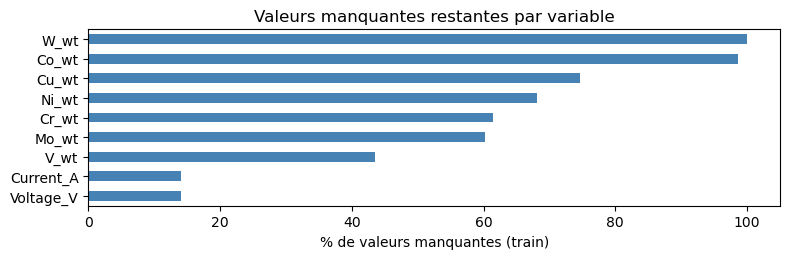

In [110]:
missing = X_train.isna().mean().mul(100).sort_values(ascending=False)
missing = missing[missing > 0]

fig, ax = plt.subplots(figsize=(8, max(2, 0.3 * len(missing))))
missing.sort_values().plot.barh(ax=ax, color="steelblue")
ax.set_xlabel("% de valeurs manquantes (train)")
ax.set_title("Valeurs manquantes restantes par variable")
plt.tight_layout()
plt.show()

Du fait que l'on ait peu de données de base sur certains inputs, on a une grande quantité de valeurs manquantes sur certains Inputs en w% par exemple W_wt et Co_wt ici. On doit vérifier si une abscence de ces élements signifie manquant ou juste non reporté. Pour ce faire, nous allons étudier le lien avec le type soudure faire "weld_type"

In [111]:
alloy_cols = ["Cu_wt", "Mo_wt", "Ni_wt", "Cr_wt", "V_wt", "W_wt", "Co_wt"]
miss = X_train[alloy_cols].isna().astype(float)

print(miss.corr().round(2))                                  # do they go missing together?
print(X_train['Weld_type'].value_counts())
print(miss.groupby(X_train["Weld_type"]).mean().round(2))    # missingness by process




       Cu_wt  Mo_wt  Ni_wt  Cr_wt  V_wt  W_wt  Co_wt
Cu_wt   1.00   0.72   0.51   0.41  0.48   NaN   0.21
Mo_wt   0.72   1.00   0.68   0.74  0.61   NaN   0.15
Ni_wt   0.51   0.68   1.00   0.71  0.34   NaN   0.18
Cr_wt   0.41   0.74   0.71   1.00  0.37   NaN   0.15
V_wt    0.48   0.61   0.34   0.37  1.00   NaN   0.11
W_wt     NaN    NaN    NaN    NaN   NaN   NaN    NaN
Co_wt   0.21   0.15   0.18   0.15  0.11   NaN   1.00
Weld_type
MMA      540
FCA       56
TSA       48
SA        46
NGSAW      9
NGGMA      4
Name: count, dtype: int64
           Cu_wt  Mo_wt  Ni_wt  Cr_wt  V_wt  W_wt  Co_wt
Weld_type                                               
FCA         1.00   0.00   0.00   0.00  0.00   1.0   1.00
MMA         0.82   0.78   0.77   0.71  0.54   1.0   0.98
NGGMA       1.00   0.00   0.00   0.00  1.00   1.0   1.00
NGSAW       1.00   0.00   0.00   0.00  1.00   1.0   1.00
SA          0.28   0.00   0.28   0.00  0.09   1.0   1.00
TSA         0.00   0.00   1.00   1.00  0.00   1.0   1.00


On voit que les absences de données sont corrélés entre elles. Pour Co_wt et W_wt, elles sont tout le temps manquantes ensembles. Du fait du peu de données et leurs présence dans les types de soudure mineurs SAA et GTAA, nous décidons de les enlever.

Pour les autres élements, nous ne savons pas de lien clair et direct entre le manque d'un élement avec le type de soudure. Nous allons juste faire l'hypothèse suivante : manquant = 0. Cette hypothèse reste à débattre car l'absence de valeur peut également signifier "non renseigné".

In [112]:
DROP_COLS = ["W_wt", "Co_wt"]
X_train = X_train.drop(columns=DROP_COLS)
num_cols = [c for c in num_cols if c not in DROP_COLS]
print(f"Variables restantes : {X_train.shape[1]} (dont {len(num_cols)} numériques)")

Variables restantes : 29 (dont 26 numériques)


Analysons maintenant nos données targets

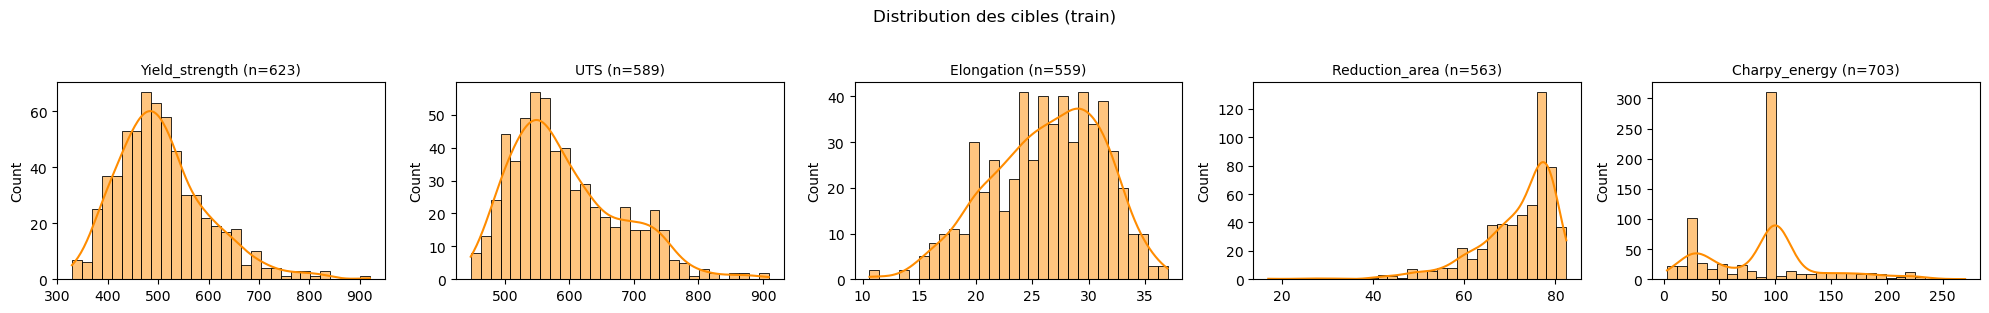

In [113]:
fig, axes = plt.subplots(1, len(TARGETS), figsize=(4 * len(TARGETS), 3))
for ax, target in zip(axes, TARGETS):
    tr, _ = load_split(target)
    sns.histplot(tr[target], bins=30, kde=True, ax=ax, color="darkorange")
    ax.set_title(f"{target} (n={len(tr)})", fontsize=10)
    ax.set_xlabel("")
plt.suptitle("Distribution des cibles (train)", y=1.03)
plt.tight_layout()
plt.show()

rien d'alarmant, hormis le pic autour de 100J de charpy_energie.

Nous étudions maintenant la corrélation entre les variables pour justifier une ACP et également pour avoir une idée de ce qui à un lien avec notre cible

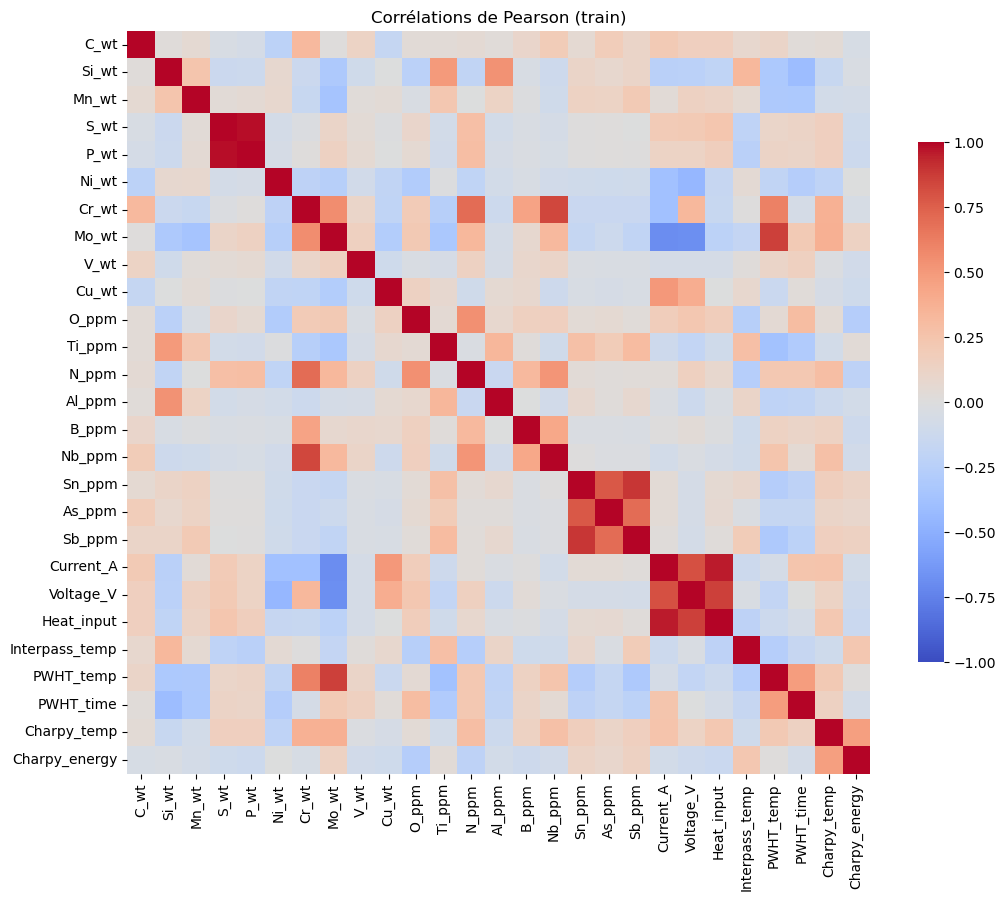

,Pearson vs Charpy_energy
Charpy_temp,0.47
O_ppm,-0.27
Interpass_temp,0.23
N_ppm,-0.21
Sb_ppm,0.15
Heat_input,-0.13
Mo_wt,0.13
Sn_ppm,0.12
P_wt,-0.12
B_ppm,-0.11


In [114]:
corr_df = train_ref[num_cols + [REF_TARGET]].dropna(axis=1, how="all")
corr = corr_df.corr(method="pearson")

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True,
            cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Corrélations de Pearson (train)")
plt.tight_layout()
plt.show()

top = corr[REF_TARGET].drop(REF_TARGET).sort_values(key=np.abs, ascending=False).head(10)
display(top.round(2).to_frame(f"Pearson vs {REF_TARGET}"))

Nous avons des corrélations entre certaines variables. Faisons l'ACP

Pour ce faire, 
nous remplacons par 0 les valeurs manquantes de w%
Pour les autres nous imputons par la médiane. Nous faisons un Pipeline de préparation à l'ACP

In [115]:
ALLOY_STRATEGY = "constant"   # "constant" (missing -> 0) or "median"

ppm_cols = [c for c in num_cols if c.endswith("_ppm")]
other_cols = [c for c in num_cols if c not in ppm_cols]


def build_pca_prep(alloy_strategy):
    """Unfitted preprocessing for the PCA (numeric features only)."""
    ppm_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="constant", fill_value=0.0, keep_empty_features=True)),
        ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        ("scale", StandardScaler()),
    ])
    other_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="median", keep_empty_features=True)),
        ("scale", StandardScaler()),
    ])
    return ColumnTransformer(
        [("ppm", ppm_pipe, ppm_cols), ("other", other_pipe, other_cols)],
        verbose_feature_names_out=False,
    ).set_output(transform="pandas")


pca_prep = build_pca_prep(ALLOY_STRATEGY)
Z_train = pca_prep.fit_transform(X_train)
print(f"Matrice standardisée : {Z_train.shape}")

Matrice standardisée : (703, 26)


Tout est prêt pour notre APC

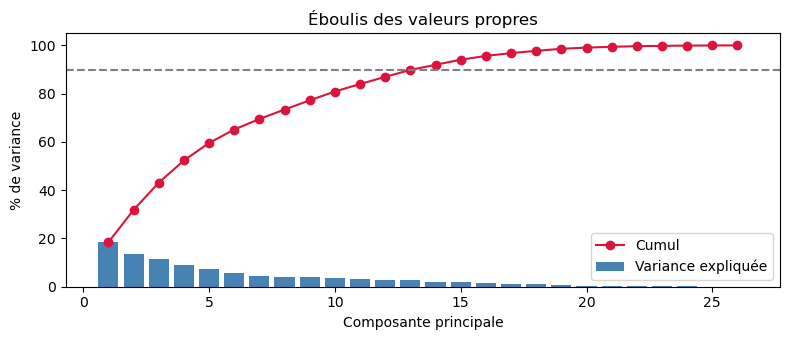

80 % de variance : 10 composantes
90 % de variance : 14 composantes
95 % de variance : 16 composantes


In [116]:
pca = PCA(random_state=0).fit(Z_train)
ratio = pca.explained_variance_ratio_
cum = np.cumsum(ratio)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(range(1, len(ratio) + 1), ratio * 100, color="steelblue", label="Variance expliquée")
ax.plot(range(1, len(ratio) + 1), cum * 100, "o-", color="crimson", label="Cumul")
ax.axhline(90, ls="--", color="gray")
ax.set_xlabel("Composante principale")
ax.set_ylabel("% de variance")
ax.set_title("Éboulis des valeurs propres")
ax.legend()
plt.tight_layout()
plt.show()

for thr in (0.80, 0.90, 0.95):
    print(f"{int(thr * 100)} % de variance : {int(np.searchsorted(cum, thr) + 1)} composantes")

Nous voyons ici que nous pouvons réduire le nombre de variables assez bien tout en expliquant pas mal de la variance de nos données. Cependant il n'y a pas de courde marqué qui permetterait de décider du nombre de variable à garder. L'ACP n'est pas une fin en soit, par la suite, nous allons l'utiliser ou non en fonction des algorithmes de ML que nous utiliserons.


In [117]:
results = {}
for strategy in ["constant", "median"]:
    Z = build_pca_prep(strategy).fit_transform(X_train)
    p = PCA(random_state=0).fit(Z)
    results[strategy] = (p, p.transform(Z)[:, :3])
    print(f"{strategy:>8}: variance cumulée PC1-3 = {p.explained_variance_ratio_[:3].sum() * 100:.1f} %")

# Absolute correlation of the scores (sign of a PC is arbitrary)
for k in range(3):
    r = np.corrcoef(results["constant"][1][:, k], results["median"][1][:, k])[0, 1]
    print(f"PC{k + 1}: |corr| entre les deux imputations = {abs(r):.2f}")
    
ALLOY_COLS = ["Cu_wt", "Mo_wt", "Ni_wt", "Cr_wt", "V_wt"]    

print(X_train[ALLOY_COLS].isna().mean().round(2))        # should be ~0.4-0.56
print(X_train[ALLOY_COLS].median().round(3))             # should not be 0

constant: variance cumulée PC1-3 = 43.1 %
  median: variance cumulée PC1-3 = 43.1 %
PC1: |corr| entre les deux imputations = 1.00
PC2: |corr| entre les deux imputations = 1.00
PC3: |corr| entre les deux imputations = 1.00
Cu_wt    0.75
Mo_wt    0.60
Ni_wt    0.68
Cr_wt    0.61
V_wt     0.44
dtype: float64
Cu_wt    0.050
Mo_wt    0.440
Ni_wt    0.170
Cr_wt    2.010
V_wt     0.005
dtype: float64


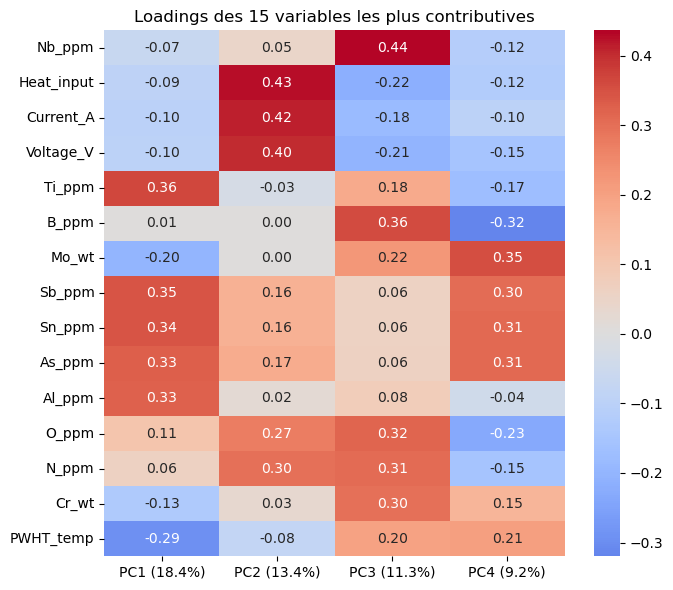

In [118]:
n_pc = 4
loadings = pd.DataFrame(
    pca.components_[:n_pc].T,
    index=Z_train.columns,
    columns=[f"PC{i + 1} ({ratio[i] * 100:.1f}%)" for i in range(n_pc)],
)
top_vars = loadings.abs().max(axis=1).sort_values(ascending=False).head(15).index

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(loadings.loc[top_vars], cmap="coolwarm", center=0, annot=True, fmt=".2f", ax=ax)
ax.set_title("Loadings des 15 variables les plus contributives")
plt.tight_layout()
plt.show()

In [119]:
pcs = pd.DataFrame(pca.transform(Z_train)[:, :4], columns=["PC1", "PC2", "PC3", "PC4"])
print(pcs.corrwith(y_train.reset_index(drop=True), method="spearman").round(2))

PC1    0.05
PC2   -0.08
PC3   -0.06
PC4    0.29
dtype: float64


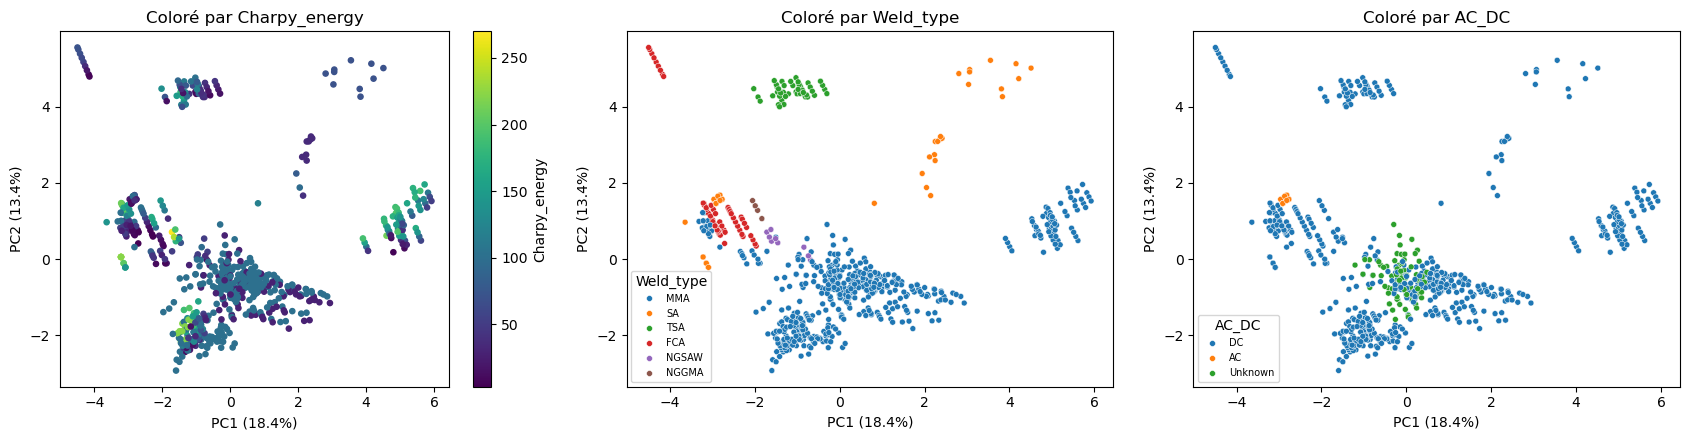

In [120]:
scores = pd.DataFrame(pca.transform(Z_train)[:, :2], columns=["PC1", "PC2"])
xlabel = f"PC1 ({ratio[0] * 100:.1f}%)"
ylabel = f"PC2 ({ratio[1] * 100:.1f}%)"

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

# 1. Colored by the reference target
sc = axes[0].scatter(scores["PC1"], scores["PC2"], c=y_train, cmap="viridis", s=14)
fig.colorbar(sc, ax=axes[0], label=REF_TARGET)
axes[0].set_title(f"Coloré par {REF_TARGET}")

# 2 and 3. Colored by categorical process variables
for ax, cat in zip(axes[1:], ["Weld_type", "AC_DC"]):
    sns.scatterplot(x=scores["PC1"], y=scores["PC2"], hue=X_train[cat].values, s=18, ax=ax)
    ax.set_title(f"Coloré par {cat}")
    ax.legend(fontsize=7, title=cat)

for ax in axes:
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
plt.tight_layout()
plt.show()

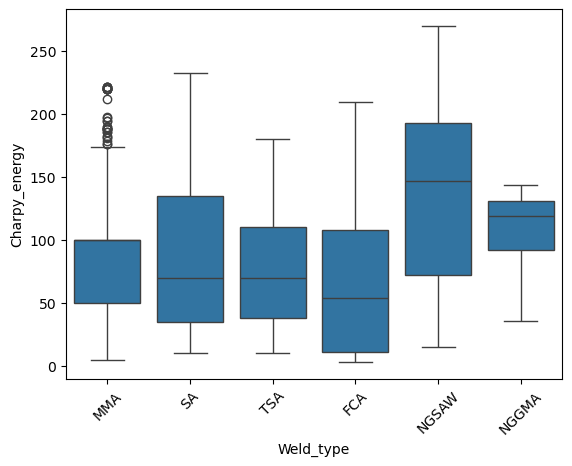

      C_wt  Si_wt  Mn_wt   S_wt   P_wt  Ni_wt  Cr_wt  Mo_wt  V_wt  Cu_wt  ...  \
33   0.088   0.37   1.59  0.011  0.010    NaN    NaN    NaN   NaN    NaN  ...   
59   0.032   0.45   2.05  0.002  0.010    NaN    NaN    NaN   NaN    NaN  ...   
73   0.032   0.45   2.05  0.002  0.010    NaN    NaN    NaN   NaN    NaN  ...   
78   0.031   0.42   1.71  0.004  0.010    NaN    NaN    NaN   NaN    NaN  ...   
84   0.032   0.45   1.27  0.008  0.010    NaN    NaN    NaN   NaN    NaN  ...   
102  0.098   0.39   2.25  0.008  0.014    NaN    NaN    NaN   NaN    NaN  ...   
119  0.031   0.42   1.71  0.004  0.010    NaN    NaN    NaN   NaN    NaN  ...   
121  0.120   0.44   1.35  0.010  0.014    NaN    NaN    NaN   NaN    NaN  ...   
151  0.032   0.45   2.05  0.002  0.010    NaN    NaN    NaN   NaN    NaN  ...   
154  0.110   0.36   2.18  0.008  0.011    NaN    NaN    NaN   NaN    NaN  ...   
172  0.120   0.43   0.86  0.011  0.014    NaN    NaN    NaN   NaN    NaN  ...   
178  0.088   0.37   1.59  0.

In [121]:
sns.boxplot(data=train_ref, x="Weld_type", y=REF_TARGET)
plt.xticks(rotation=45)
plt.show()

print(X_train.loc[scores["PC1"] > 5])

RESTE A FAIRE, ANALYSER LES GRAPHES DE ACP POUR LES DIFFERENTES CIBLES ["Yield_strength", "UTS", "Elongation", "Reduction_area", "Charpy_energy"]